<a href="https://colab.research.google.com/github/mdruwaid/college-labs/blob/main/DL-labs/Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.83MB/s]


In [11]:
class Autoencoder(nn.Module):
  def __init__(self):
    super(Autoencoder, self).__init__()
    # Encoder
    self.encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32)
    )
    # Decoder
    self.decoder = nn.Sequential(
    nn.Linear(32, 64),
    nn.ReLU(),
    nn.Linear(64, 128),
    nn.ReLU(),
    nn.Linear(128, 28*28),
    nn.Sigmoid(),
    nn.Unflatten(1, (1, 28, 28))
    )
  def forward(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

In [13]:
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 5
for epoch in range(num_epochs):
  for data, _ in train_loader:
    output = model(data)
    loss = criterion(output, data)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/5], Loss: 0.0348
Epoch [2/5], Loss: 0.0274
Epoch [3/5], Loss: 0.0242
Epoch [4/5], Loss: 0.0215
Epoch [5/5], Loss: 0.0186


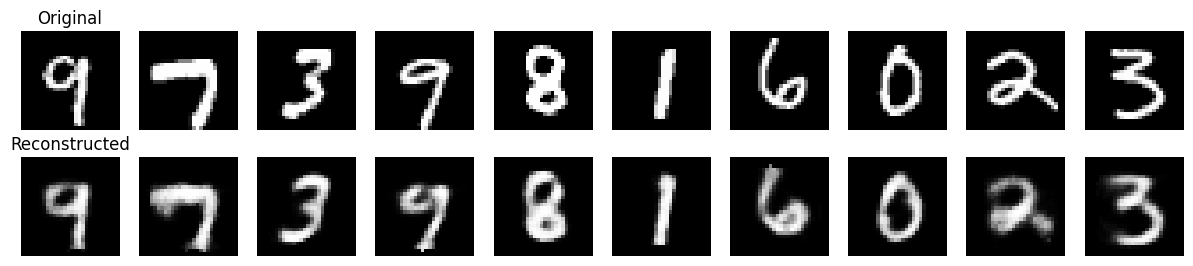

In [16]:
# Get a batch of test images
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=10, shuffle=True)
dataiter = iter(test_loader)
images, _ = next(dataiter)
# Pass through autoencoder
reconstructed = model(images)
# Plot original and reconstructed images
fig, axes = plt.subplots (2, 10, figsize=(15, 3))
for i in range(10):
  axes[0, i].imshow(images[i][0], cmap='gray')
  axes[0, i].axis('off')
  axes[1, i].imshow(reconstructed[i][0].detach(), cmap='gray')
  axes[1, i].axis('off')
axes[0, 0].set_title('Original')
axes[1, 0].set_title('Reconstructed')
plt.show()